# General mapper pipeline

**Author:** Erik Amézquita

**Date:** November 2025

This is a short notebook on how to generate Mapper graphs with a variety of parameters. Mapper is one of the many tools available from Topological Data Analysis (TDA). In this case, the analysis is targeted to RNAseq data. Choosing the right parameters is a combination of math, art, and some luck. This is by no means an exhaustive list of things to try, but it (hopefully) will provide a good starting point from which finer analyses can be devised.

<span style='font-size:3em;'>&#10024;</span>

You don't need to know how to code to use this notebook. If you've managed to get a open this very notebook with Jupyter, you've already done the hardest part. Look for the sparkle symbols (&#10024;) below that will encourage where to change values. Don't worry about any code block without spakles (but remember to run it once). 

Some general observations of what to expect (there might be exceptions)
- Changing **lens** will affect the **most** the final color distribution (and possibly shape) of the mapper graph
- Choosing between using one or two lens functions at time will probably affect the results visibly
- The higher the number of bins (`cubes`), the more nodes you'll have in the mapper
- The higher the overlap percentage, the more edges you'll have between nodes

---

# Part I: Imports

We start importing some standard libraries and sublibraries for non-TDA stuff. For the mapper-specific computations, we'll use `kmapper.`

In [1]:
import os
import itertools
import numpy as np
import kmapper as km
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import cluster, preprocessing, metrics, decomposition, manifold, ensemble, neighbors

# Part II: On the data and its purpose

The data contains RNAseq read counts for 56k genes and 6 experiments with 2 repetitions each (12 rice samples in total). These samples follow the naming convention:
- B = Resistant line
- I = Susceptible line 1
- Z = Susceptible line 2
- M = Mock
- A = Bacterial inoculation
- 24 = RNA collected 24 hours after infection

Thus,
- BA24 = Resistant line, Bacterial inoculation, RNA collected 24 hours after infection
- IM24 = Susceptible line 1, Mock, RNA collected 24 hours after infection

To make these reads comparable to each other, they will be transformed to TPM (transcripts per million). The code below does that for you. 
[Read here if you are curious on what TPM means](https://www.rna-seqblog.com/rpkm-fpkm-and-tpm-clearly-explained/).

&#10071;**Important:** Make sure that Ajay's data is inside the `raw` folder of your downloaded github folder. I did not want to publicly post his data without his explicit consent.

## Overall goal

The goal is to figure out which genes are the most differentially expressed across the six experiments. Identifying such genes is crucial to later explore pathways that will enventually result in rice varieties that are genetically immune to bacterial attacks.

The standard way to assess if a gene is differentially expressed between two samples is to check for its *fold-change* ratio:

$$\text{FC} = \frac{\text{Expression of Sample A}}{\text{Expression of Sample B}}$$

For a given gene  for example, if sample $A$ has an expression value of 10 and sample $B$ only has 5, then $FC = 2$, which literally means that the expression level from $B$ to $A$ has increased 2-fold. In principle, we are looking for genes with high $FC$ values. However, if the expression level of $B$ is very close to 0 (because the gene is not that important to begin with or there was a problem in the sequencing pipeline), then its $FC$ will be very high. We don't want that.

On top of that, in this case there are only 2 replicates per experiment, so doing any meaningful statistics will be hard. Also: I'm not a bioinformatician nor a statistician. I read quickly through [DESeq2](https://doi.org/10.1186/s13059-014-0550-8) (the gold standard) to come up with a crude way to compute $FC$ values and adjusting them for cases where sample $B$ is poorly expressed.

In short, I computed adjusted $FC$ scores to assess for differential expression levels for
- BA versus BM
- IA versus IM
- ZA versus ZM
- BA versus IA
- BA versus ZA
- BM versus IM
- BM versus ZM

That is, 7 $FC$s are computed and then they are simply added to have a single number per gene.

We finally take the logarithm of this number to obtain a single $LFC$ value, *log-fold-change*.

In [2]:
# A crude way to compute fold-change values adjusting for poorly expressed genes
# Inspired by DESeq2

def foldchange(comparison, rpk, tpm, lines, reps, alpha=0.01):
    
    laba = ['{}_{}'.format(lines[comparison[0]], r) for r in reps ]
    labm = ['{}_{}'.format(lines[comparison[1]], r) for r in reps ]
    
    foo = rpk.loc[tpm.index, laba + labm].mean(axis=1) - rpk.loc[tpm.index, laba + labm].sem(axis=1)
    attenuate = preprocessing.minmax_scale(foo, (foo.min(), np.quantile(foo, 1-alpha)))
    attenuate[attenuate > 1] = 1

    a = tpm[laba].mean(axis=1)
    m = tpm[labm].mean(axis=1)
    
    am = a.div(m)
    ma = m.div(a)
    
    return  attenuate*am.where(am > ma, ma)

## Read, transform, and clean the count data

- Read the count data
- Transform the read counts to TPM
- Remove genes that have the exact same expression across all samples
- Remove the genes that have less than 1 TPM expressed on average across all samples
- Compute $FC$s for the 7 pairs mentioned above, add them, and log-transform it.
- Bound the highest values for better visualization

In [3]:
fs = 12
src = os.pardir + os.sep + 'raw' + os.sep
dst = os.pardir + os.sep + 'outputs' + os.sep
if not os.path.isdir(dst):
    os.mkdir(dst)

reps = [1,2]

filename = src + 'readCounts_Xa7_msu_v7.csv'
data = pd.read_csv(filename).set_index('Geneid')

lines = ['BA24','BM24','IA24','IM24','ZA24','ZM24']
comparisons = [(0,1),(2,3),(4,5),(0,2),(0,4),(1,3),(1,5)]

full_lines = list(itertools.chain(*[[ '{}_{}'.format(l,r) for r in reps ] for l in lines]))

rpk = data[full_lines].div(data['Length'], axis='index')
tpm = rpk.div(rpk.sum(axis=0)/1e6, axis='columns')
print('Original dataframe dimensions:\t', tpm.shape)

nonzero_mask = pd.Series(True, index=tpm.index)
for l in lines:
    nonzero_mask[ tpm[ ['{}_{}'.format(l,r) for r in reps] ].mean(axis=1) == 0 ] = False

tpm = tpm.loc[nonzero_mask].loc[ tpm.loc[nonzero_mask[nonzero_mask].index].sum(axis=1) > tpm.shape[1] ]
print('After initial cleanup:\t', tpm.shape)

fcs = dict()
for comp in comparisons:
    key = (lines[comp[0]],lines[comp[1]])
    fcs[key] = foldchange(comp, rpk, tpm, lines, reps)

fc = sum(fcs.values())
lfc = np.log10(fc)

alpha = 0.01
mini, maxi = np.quantile(lfc, [alpha, 1-alpha])
chopped_lfc = lfc.copy()
chopped_lfc[chopped_lfc < mini] = mini
chopped_lfc[chopped_lfc > maxi] = maxi

tpm.head()

Original dataframe dimensions:	 (55986, 12)
After initial cleanup:	 (20015, 12)


,BA24_1,BA24_2,BM24_1,BM24_2,IA24_1,IA24_2,IM24_1,IM24_2,ZA24_1,ZA24_2,ZM24_1,ZM24_2
Geneid,,,,,,,,,,,,
LOC_Os01g01010,23.133621,22.533723,36.365026,20.774988,24.241255,19.080527,26.835956,27.504311,21.648054,17.114662,29.874780,26.511374
LOC_Os01g01030,1.441114,1.193850,1.692808,1.596698,2.288079,2.017914,1.373798,2.779524,1.463244,2.347877,2.583877,3.091158
LOC_Os01g01040,19.958814,13.469881,23.734983,20.503570,19.652930,19.996415,19.333245,21.402004,17.847978,17.359653,18.974958,19.536692
LOC_Os01g01050,19.626632,18.963796,32.713350,26.421081,21.307651,20.433110,23.974987,25.739951,20.373498,15.322905,26.671646,26.543966
LOC_Os01g01060,185.862879,141.570981,134.388872,129.749051,144.269360,215.770041,132.849454,102.662829,186.940809,203.003702,114.648839,112.747784


# A peek of the LFCs

Log fold-change values for each of the 7 comparisons and their sum. In general, we want to focus on genes with LFC value larger than $1$, because it would mean that there was an increment in expression level between samples $A$ and $B$.

Notice that only a tiny fraction of genes report $FC$ values larger than 1 for each of the 7 comparisons.

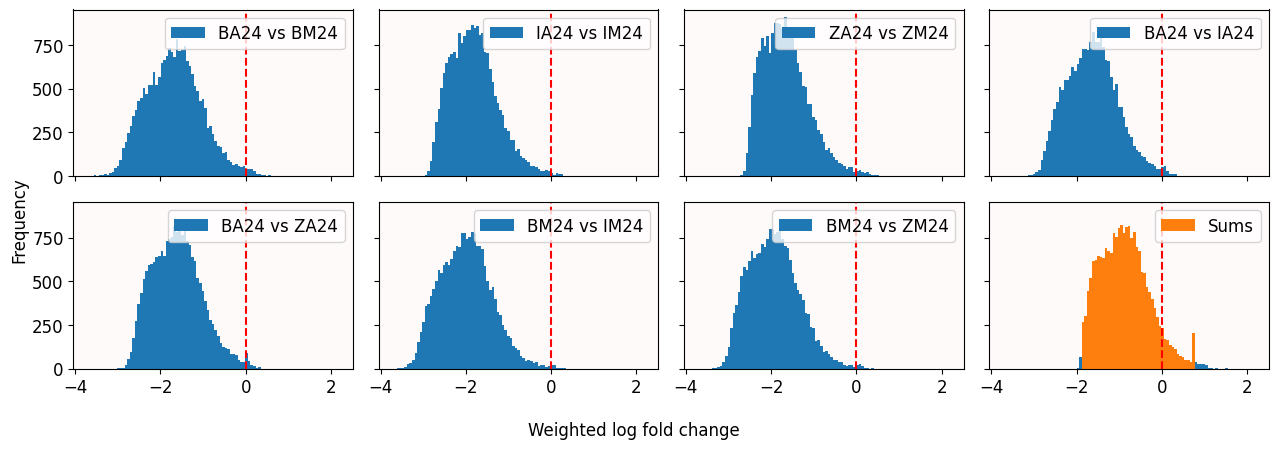

In [4]:
bins = np.linspace(np.log10(min(list(map( min, fcs.values())))), lfc.max(), 100)

fig, ax = plt.subplots(2,4,figsize=(13,4.5), sharex=True, sharey=True)
ax = ax.ravel(); i = 0

for i,key in enumerate(fcs):
    ax[i].hist(np.log10(fcs[key]), bins=bins, label=' vs '.join(key), zorder=1)
ax[-1].hist(lfc, bins=bins, zorder=1)
ax[-1].hist(chopped_lfc, bins=bins, label='Sums', zorder=1)

for i in range(len(ax)):
    ax[i].axvline(0, ls='dashed', c='r', zorder=2)
    ax[i].set_facecolor('snow')
    ax[i].tick_params(labelsize=fs)
    ax[i].legend(loc='upper right', fontsize=fs)

fig.supylabel('Frequency', fontsize=fs)
fig.supxlabel('Weighted log fold change', fontsize=fs)
fig.tight_layout()

# A look on some genes

- 8 genes with low expression levels across the board: they get an $FC$ value close to 0
- 8 genes with very high expression of IM24: they have $FC$ values larger than 7

In [5]:
N = 8
#foo = tpm.loc[bb.sort_values().iloc[ list(range(N)) + list(range(-N,0)) ].index]
foo = tpm.loc[tpm.sort_values(by='IM24_1').iloc[ list(range(N)) + list(range(-N,0)) ].index]
foo['fc'] = fc.loc[foo.index]

foo.round(3)

,BA24_1,BA24_2,BM24_1,BM24_2,IA24_1,IA24_2,IM24_1,IM24_2,ZA24_1,ZA24_2,ZM24_1,ZM24_2,fc
Geneid,,,,,,,,,,,,,
LOC_Os07g28880,3.645,1.965,0.000,1.234,2.074,1.363,0.000,0.154,2.793,2.346,3.298,1.745,0.048
LOC_Os01g31570,0.996,5.788,4.006,2.925,6.549,0.748,0.000,5.443,3.448,0.651,3.103,4.122,0.024
LOC_Os03g44642,1.220,3.284,0.000,0.361,1.480,1.247,0.000,0.847,3.131,3.309,0.575,0.391,0.041
LOC_Os02g54140,0.742,1.225,0.000,0.707,4.643,18.288,0.000,0.316,1.072,13.822,0.824,0.438,0.230
LOC_Os03g06780,0.836,1.973,3.544,1.753,3.248,1.614,0.000,0.548,3.597,3.280,0.000,0.127,0.188
LOC_Os11g42290,2.435,2.064,0.309,0.000,5.986,1.263,0.000,0.266,1.325,4.735,0.000,0.492,0.082
LOC_Os06g34330,1.782,0.277,1.744,0.000,2.512,5.777,0.000,0.250,0.000,1.249,0.000,1.157,0.064
LOC_Os06g32980,2.927,1.671,0.341,0.351,1.157,2.356,0.000,0.206,1.676,7.216,0.000,0.063,0.347
LOC_Os05g15770,1645.116,1425.488,2765.878,6118.615,3811.107,6102.722,6200.651,3500.357,2969.475,3252.975,4947.434,5682.641,13.167


## Sidenote: PCA

Since we're here, let's do a PCA with all the values for the 12 samples. Can we find a continuum on how gene expression values and distributions change?

In [6]:
scaler = preprocessing.StandardScaler(copy=True, with_std=True, with_mean=True).fit(tpm)
df = scaler.transform(tpm)

# Let's reduce our data to just 2 dimensions
PCA = decomposition.PCA(n_components=2, random_state=42, svd_solver='full').fit(df)

pca = PCA.transform(df).astype('float32')
explained_ratio = 100*PCA.explained_variance_ratio_

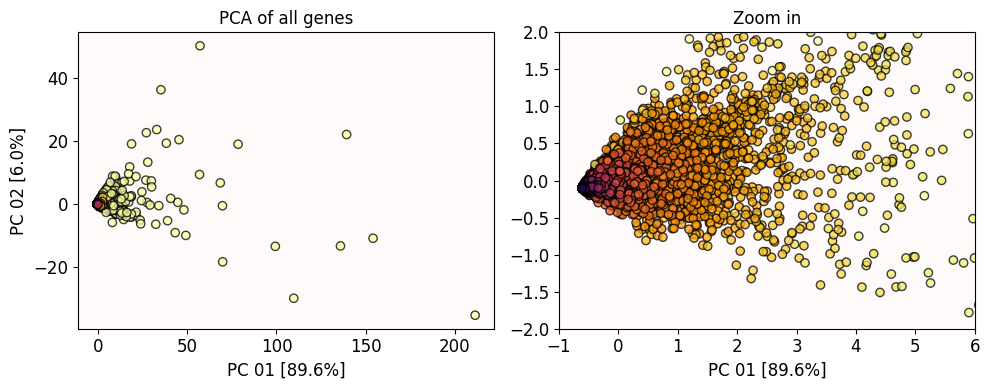

In [7]:
fig, ax = plt.subplots(1,2, figsize=(10,4))

for a in ax.ravel():
    a.scatter(*pca.T, c=chopped_lfc, cmap='inferno', ec='k', marker='o', alpha=.75)
    a.set_title('PCA of all genes', fontsize=fs)
    a.set_xlabel('PC 01 [{:.1f}%]'.format(explained_ratio[0]), fontsize=fs)
    a.set_facecolor('snow')
    a.tick_params(labelsize=fs)
ax[0].set_ylabel('PC 02 [{:.1f}%]'.format(explained_ratio[1]), fontsize=fs);
ax[1].set_xlim(-1,6); ax[1].set_ylim(-2,2)
ax[1].set_title('Zoom in', fontsize=fs)

fig.tight_layout()

Bright colored points (yellow) correspond to high $FC$s, while dim colored points correspond to low $FC$s. All I see in reality is a large clump with some offshoots. There seems to be effectively a continuum left-to-right matching an increase of $FC$.

Can we say more with mapper?

---

# Part III: Mapper setup

Before we get into Mapper, let's do some setup. You'll just need to run the code below only once.

As you know by now, Mapper has lots and lots of moving pieces. This is good because it let's us adjust the pieces to whatever goal we have in mind. But it is bad because it is not so obvious what is the right combination of ingredients.

Your task is to explore what do different moving pieces do by making lots and lots of graphs and keeping a log of your observations.

In [8]:
# Code to get mapper started object
mymapper = km.KeplerMapper(verbose=1)

# Define Nerve
nerve = km.GraphNerve(min_intersection=1)

KeplerMapper(verbose=1)


## Filter (lens) functions

The most important moving piece of mapper is the lens (filter function). Different lenses will highlight different features of the data structure. Remember that a lens is essentially a way to assign a *single* number to each of the 20K genes we are dealing with. Below are 6 functions to get us started:

- **Lens 1 (isolation)**
    - Isolation forest index: How *anomalous* is the gene? Is its expression level common or rare compared to the rest?
- **Lens 2 (sd)**
    - Standard deviation of the expression levels
- **Lens 3 (sd mean)**
    - Standard deviation divided the mean
- **Lens 4 (high low):**
    - Expression difference between the 2nd highest and 2nd lowest samples
- **Lens 5 (pc1):**
    - PC1 value (it already expresses 90% of the total variance)
- **Lens 6 (euclidean):**
    - $L_2$ norm _aka_ Euclidean norm: how close to 0 expression is the gene?
 
&#10071; **Important:** Make note of the name in the parenthesis. Note that the names are all lowercase.

In [14]:
# Compute different filter functions


model = ensemble.IsolationForest(random_state=42).fit(tpm.values)
lens1 = model.decision_function(tpm.values)

lens2 = tpm.std(axis=1)

lens3 = tpm.std(axis=1)/tpm.mean(axis=1)

a,b,c = np.sort(tpm.values, axis=1)[:, [1,-2,-1]].T
lens4 = (b-a)

lens5 = pca[:,0]

lens6 = np.sqrt(np.sum(tpm.values**2, axis=1))

# Setting up a dictionary

keys = ['isolation', 'sd', 'sd mean', 'high low', 'pc1', 'euclidean']
titles = ['Isolation Forest', 'SD', 'SD/Mean', 'High - Low', 'PC 01', 'Euclidean norm']
lenses = [lens1, lens2, lens3, lens4, lens5, lens6]

mini = 1e-6
ldict = dict()
for i in range(len(keys)):
    
    lens = preprocessing.minmax_scale(lenses[i], (mini,1))
    ldict[keys[i]] = {'lens': lens, 'title':titles[i]}
    ldict['log ' + keys[i]] = {'lens': np.log10(lens), 'title':'log(' + titles[i] + ')'}

We can take a look at how the values are distributed:

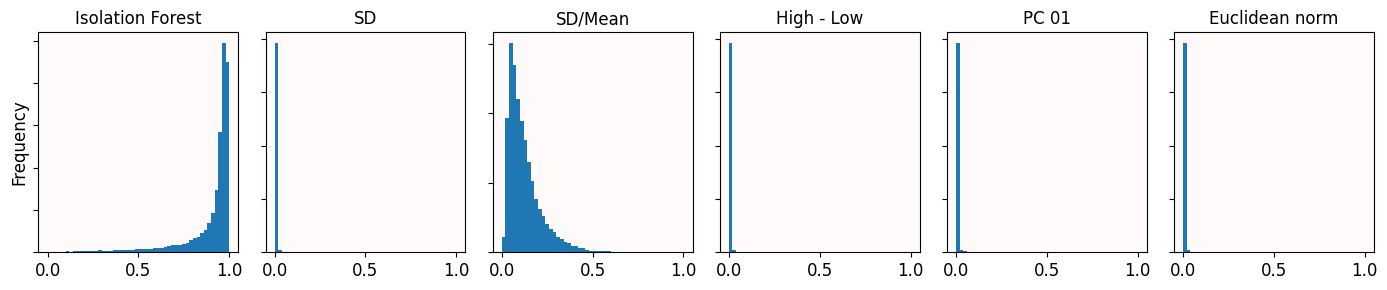

In [15]:
fig, ax = plt.subplots(1,len(keys),figsize=(14,3))

for i in range(len(ax)):
    lens = ldict[keys[i]]
    ax[i].hist(lens['lens'], bins=50)
    ax[i].tick_params(labelsize=fs, labelleft=False)
    ax[i].set_facecolor('snow')
    ax[i].set_title(lens['title'], fontsize=fs)
ax[0].set_ylabel('Frequency', fontsize=fs)
fig.tight_layout()

Notice that for every lens, the values are pretty much concentrated around 0 (or 1). Which means that almost all the genes have the same values. In general, this is to be expected.

Moreover, we know that only a handful of genes are differentially expressed. It makes sense that the non-differentially expressed genes (most of them) for a very large clump. This could be useful for our purpose.

### Additional log-transforms

But we can spread out the values. Instead of having a large clump of genes with the same lens value, we can log-transform it and spread it around. Following similar names and order:

1. log isolation
1. log sd
1. log sd mean
1. log high low
1. log pc1
1. log euclidean

&#10071;**Important:** Make note of the names of the lenses named right above. Note that the names are all lowercase.

&#10071;&#10071;**Important:** Because the values are much more spread out, Log-lenses tend to generate prettier but much more complicated graphs. Just because something looks complicated does not necessarily mean it is better.

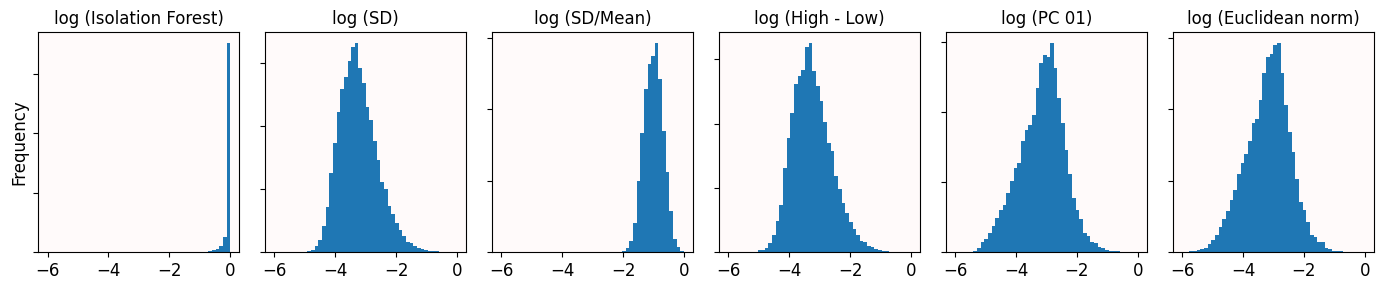

In [16]:
fig, ax = plt.subplots(1,len(keys),figsize=(14,3))

for i in range(len(ax)):
    lens = ldict['log ' + keys[i]]
    ax[i].hist(lens['lens'], bins=50)
    ax[i].tick_params(labelsize=fs, labelleft=False)
    ax[i].set_facecolor('snow')
    ax[i].set_title(lens['title'], fontsize=fs)
ax[0].set_ylabel('Frequency', fontsize=fs)
fig.tight_layout()

---

<span style='font-size:4em;'>&#10024;</span>

# Part IV: Defining concrete values for mapper

Now the fun really begins: time for **you** to choose some moving parts and see what happens. There's an example below.

## Define a clustering method: DBSCAN (`eps`)

There are several [clustering algorithms available](https://scikit-learn.org/stable/api/sklearn.cluster.html) out there. And each of these algorithms has its own moving pieces, oh my. We will focus on just one to keep things simple: DBSCAN. Usually matches your intuition. Kind of the gold standard. The one parameter that matters is epsilon (`eps` or &#949;):

- &#10024; `eps`: How close must be the points to be considered?
    - Low `eps` will favor lots of small clusters.
    - Large `eps` will tend to give you few, large clusters.
    - Try values `eps`: 0.1, 0.2, 0.3, 0.4, 0.5, 0.6

## Define the number of bins (`bins`) and their overlap (`overlap`)

- &#10024; `bins`: Into how many bins are we going to split the data?
    - Low `bins` will produce few nodes resulting in a possibly too simple graph
    - Large `bins` will produce more nodes resulting in a possibly too complex graph
    - Try values `bins`: 20, 30, 40, ..., and so on till 120
    - You can try values larger than 120, but they might take longer to compute
 
- &#10024; `overlap`: How much overlap&mdash;percentage-wise&mdash; is there between consecutive bins?
    - Low `overlap` will only link truly close nodes but will produce few edges
    - High `overlap` will produce many more edges, but this might muddle the picture
    - Try values `overlap`: 0.2, 0.3, ..., 0.8
 
## Decide the filter function to use `lens`

This is possibly what will influence the final mapper shape the most. And you can even choose if you will be considering one or two filter functions at a time. (In principle you can consider 3,4,5,etc. filter functions at a time, but computations get super long and complex).

You can choose from 12 options available. The 6 regular filters and their 6 log versions, as defined above.

1. isolation
1. sd
1. sd mean
1. high low
1. pc1
1. euclidean

- &#10024; `lens`: Select one or two lens names. If you choose two, the order does not matther.

**Important:** Syntax is important to avoid code errors below.

- Make sure that you type the lens names exactly as indicated. 
- *Each* of the lens names should be between apostrophes `'` (you'll see that the text is a reddish color)
- If you use two lenses, these are separated by a comma `,`
- The whole thing always should be between square brackets `[ ]`

# Let's look at an example

You will only need to make edits to one of the cells below. 

Say that we want to compute the mapper graph using 100 bins, with 30% overlap between them, and a clustering epsilon of 0.3. We want to use only one filter: the standard deviation filter. Then the cell below should look like:

```python
eps = 0.3
bins = 100
overlap = 30
lens = [ 'sd' ]
```

<span style='font-size:2em;'>&#9889;</span> That's it. That's all the code you have to write! You don't have change anything else.

## Another example

Now say we want to use 120 bins, with 50% overlap between them, with an epsilon of 0.2, and *two* filters: standard deviation *and* the log-transformed Isolation Forest index.

```python
eps = 0.2
bins = 120
overlap = 50
lens = [ 'sd' , 'log isolation' ]
```

# &#11088; &#11088; Your turn &#11088; &#11088;

In [28]:
# Edit the code here

eps = 0.2
bins = 120
overlap = 50
lens = ['sd', 'log isolation']
lens = ['sd']

# That's it. 
# Now you just need to run the cell below and check the resulting mapper graph
# Remember to run the cell below every time you edit these parameters

In [31]:
# Just run it

# Define clustering algorithm

clusterer = cluster.DBSCAN(eps=eps, metric='correlation', n_jobs=1)
cmethod = clusterer.__module__.split('.')[-1][1:].lower() + '{:.1f}'.format(clusterer.eps).replace('.',',')
#clusterer = cluster.KMeans(n_clusters=2, random_state=42)

# Define mapper cover
cover = km.cover.Cover(n_cubes=bins, perc_overlap=overlap/100.)

# Define lens function
lensf = np.column_stack( [ ldict[l]['lens'] for l in lens ] ).squeeze()

# Create mapper graph with nodes, edges and meta-information.
graph = mymapper.map(lens=lensf,
                     X=tpm,
                     clusterer=clusterer,
                     cover=cover,
                     nerve=nerve,
                     precomputed=False,
                     remove_duplicate_nodes=True)

nunique = len(np.unique(list(itertools.chain(*[ graph['nodes'][key] for key in graph['nodes'] ]))))
print('\nMapper graph contains {} unique genes [{:.2f}% of total]\n\n'.format(nunique, 100*nunique/len(tpm)))

# Specify file to save html output

key = '+'.join(lens).replace(' ','_')
ktitle = ' and '.join([ ldict[l]['title'] for l in lens ])

fpath =  dst + "{}_B{}_Ov{}_{}.".format(key, bins, overlap, cmethod)
figtitle = "{}; #Bins {}; Overlap: {}%; DBSCAN &#949; {}".format(ktitle, bins, overlap, clusterer.eps)

_ = mymapper.visualize(graph,
                       path_html=fpath + 'html',
                       title=figtitle,
                       color_values=chopped_lfc,
                       colorscale=None,
                       color_function_name=["log-fold change"],
                       nbins = 10)
                       #include_searchbar=True)

Mapping on data shaped (20015, 12) using lens shaped (20015,)

Creating 120 hypercubes.
No duplicate nodes found to remove.


Created 18 edges and 19 nodes in 0:00:02.686914.
Mapper graph contains 19850 unique genes [99.18% of total]
../outputs/sd_B120_Ov50_dbscan0,2.
SD; #Bins 120; Overlap: 50%; DBSCAN &#949; 0.2
Wrote visualization to: ../outputs/sd_B120_Ov50_dbscan0,2.html


# &#9889; You did it

If no errors were shown, you should find the generated mapper graph inside the `outputs` folder. It is an HTML file that you can open with any web browser. The file name should tell you the filter(s) used, the number of bins, overlap, and `eps` parameter for DBSCAN.

## Things to look for before you move to the next combination of mapper parameters

Check the number of unique genes being included in the graph. This is mentioned in the cell above. You should see a message that reads something like:

```
Mapper graph contains 19850 unique genes [99.18% of total]
```

`kmapper` will not include genes that are a cluster of their own. This happens whenever a gene is waaay too different from the rest and mapper is unable to cluster it/pair it with somebody else. While missing a few genes here and there is almost impossible, make sure that mapper is including a good chunk of the total. In this case, we are including 99.2%, which is pretty good. 

You can also check that number in the actual mapper graph:

1. Open the graph
1. Click on the `[+] Mapper Summary` tab
1. You should see a number next to `Unique Samples`: the closer this number is to 20,015, the better.

## Mapper shape

Finally, check the mapper graph. Look for anything that looks *interesting*. In general, simple strands are boring (unless the coloring pattern is much more interesting than a simple continuum). 
- Bifurcations are cool.
- Flares are cool
- Large loops are cool

Also look if colors, especially yellow colored-nodes, follow an interesting placement within the graph.

**Note:** The node size in the graph is **not** proportional to the number of genes clustered in it. What might look like an 

# &#9889; Now go and make some pretty mapper graphs!